In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
uva_gifts = pd.read_csv('ForeignGifts_edu.csv').query("`Institution Name` == 'University of Virginia'")
uva_gifts

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd
...,...,...,...,...,...,...,...,...,...,...
26328,26329,374500,University of Virginia,Charlottesville,VA,43602,99885,Contract,SWEDEN,AutoLiv Development AB
26329,26330,374500,University of Virginia,Charlottesville,VA,43697,1000000,Monetary Gift,SWITZERLAND,Lawrence D & Karin S Howell
26330,26331,374500,University of Virginia,Charlottesville,VA,43796,500000,Monetary Gift,GUERNSEY,Harvest Group Holding (PTC Limited)
26331,26332,374500,University of Virginia,Charlottesville,VA,43803,146810,Contract,THE NETHERLANDS,Pantarhei Oncology BV


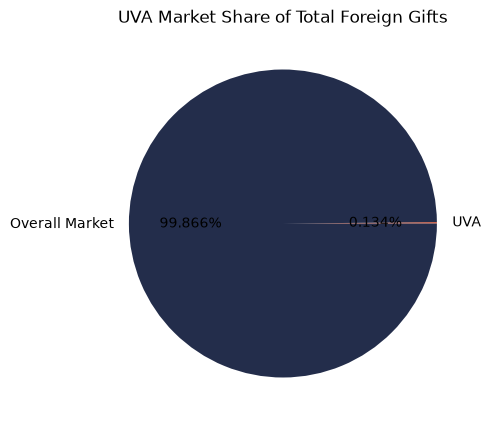

/var/folders/6d/bhdr__8d39z9s0lz5122v7380000gn/T/ipykernel_80146/2315033797.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


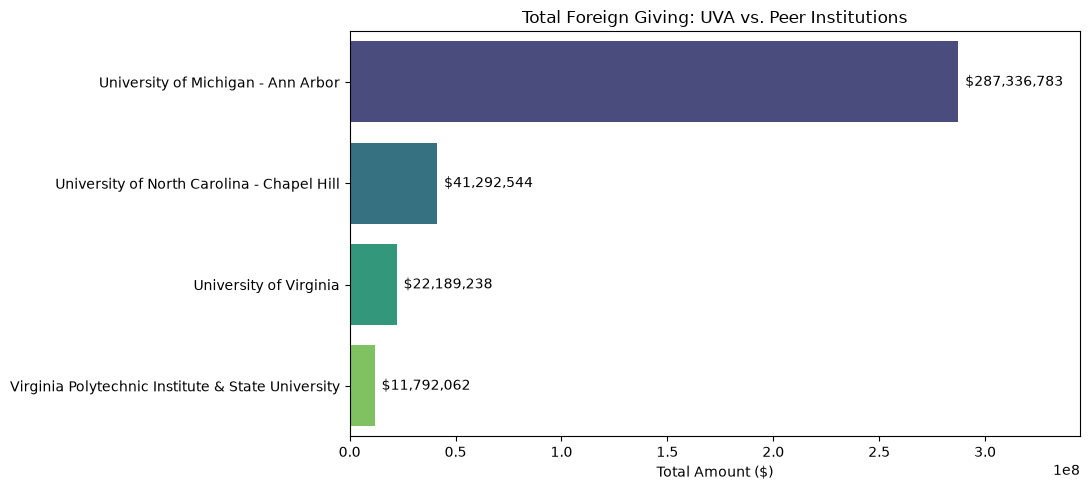

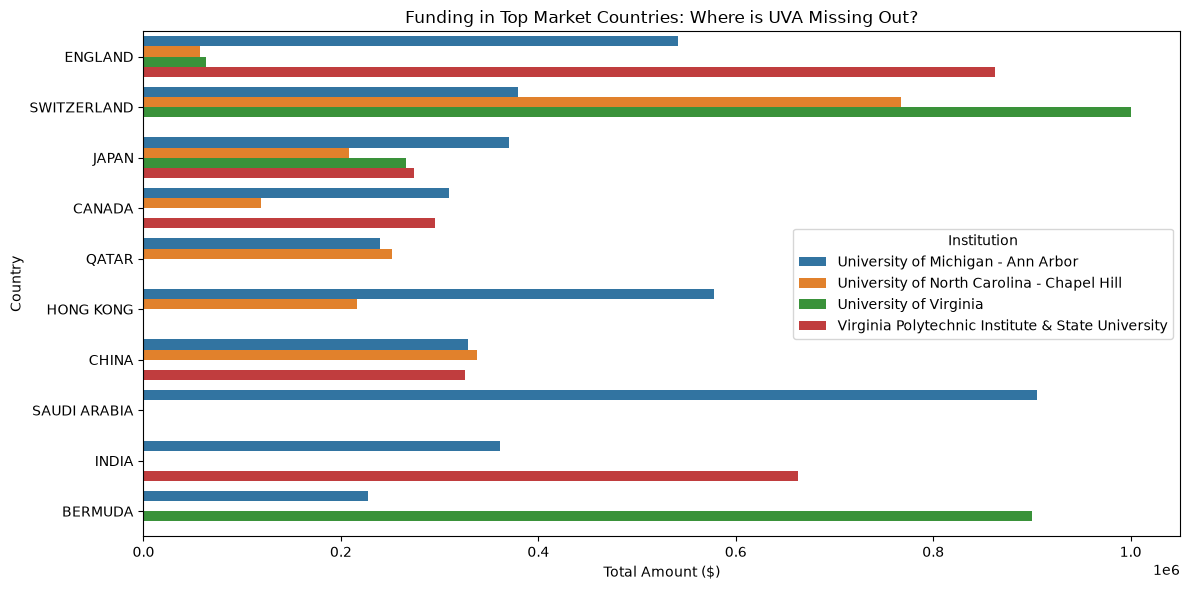

In [18]:


df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)


df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')


peer_group = [
    'University of Virginia', 
    'University of North Carolina - Chapel Hill', 
    'University of Michigan - Ann Arbor', 
    'Virginia Polytechnic Institute & State University'
]
#this makes a dataframe with UVA and its peers
peers_df = df[df['institution_name'].isin(peer_group)]

# This is UVA vs. the entire market overall
plt.figure(figsize=(7, 5))
uva_total = peers_df[peers_df['institution_name'] == 'University of Virginia']['foreign_gift_amount'].sum()
market_total = df['foreign_gift_amount'].sum()
plt.pie([uva_total, market_total - uva_total], 
        labels=['UVA', 'Overall Market'], 
        autopct='%1.3f%%', colors=['#F84C1E', '#232D4B'])
plt.title('UVA Market Share of Total Foreign Gifts')
plt.show()

# Total Giving - UVA vs. Peers
plt.figure(figsize=(11, 5))
peer_totals = peers_df.groupby('institution_name')['foreign_gift_amount'].sum().reset_index()

ax = sns.barplot(
    data=peer_totals.sort_values(by='foreign_gift_amount', ascending=False),
    x='foreign_gift_amount',
    y='institution_name',
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', padding=5)

plt.xlim(0, peer_totals['foreign_gift_amount'].max() * 1.2)

plt.title('Total Foreign Giving: UVA vs. Peer Institutions')
plt.xlabel('Total Amount ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

 
# Identifying new sources by finding the top 10 countries giving to the overall market
top_countries = df.groupby('country_of_giftor')['foreign_gift_amount'].sum().nlargest(10).index
strategy_df = peers_df[peers_df['country_of_giftor'].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.barplot(data=strategy_df, x='foreign_gift_amount', y='country_of_giftor', hue='institution_name', errorbar=None)
plt.title('Funding in Top Market Countries: Where is UVA Missing Out?')
plt.xlabel('Total Amount ($)')
plt.ylabel('Country')
plt.legend(title='Institution')
plt.tight_layout()
plt.show()

UVA Recieved Around $22.2 Million in Gifts, capturing 0.13% of total market, falling behind peer institutes, such as, University of Michigan and UNC Chapill Hill but recieved more gift than Virginia Tech. We believe that UVA should target major donor nations where some of its peers have demonstrated much success.

Top 5 Countries by Total Amount of Gift

In [4]:
# top 5 donor countries
top_5_countries = uva_gifts.groupby('Country of Giftor')['Foreign Gift Amount'].agg('sum').sort_values(ascending=False).head(5).reset_index()
top_5_countries.style.format({'Foreign Gift Amount': '${:,.2f}'})

,Country of Giftor,Foreign Gift Amount
0,BANGLADESH,"$4,228,589.00"
1,SWEDEN,"$4,007,552.00"
2,TANZANIA,"$2,776,447.00"
3,SWITZERLAND,"$2,000,000.00"
4,ENGLAND,"$1,950,666.00"


/var/folders/6d/bhdr__8d39z9s0lz5122v7380000gn/T/ipykernel_80146/3750162225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_countries, x='Country of Giftor', y='Foreign Gift Amount', palette='viridis')


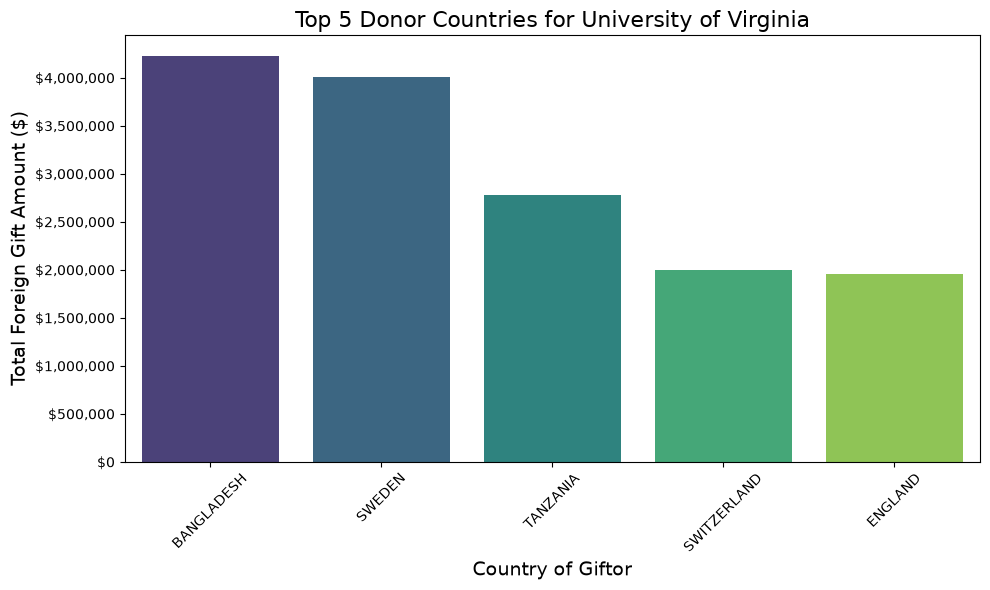

In [5]:
# bar chart for top 5 donor countries
plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_countries, x='Country of Giftor', y='Foreign Gift Amount', palette='viridis')
plt.title('Top 5 Donor Countries for University of Virginia', fontsize=16)
plt.xlabel('Country of Giftor', fontsize=14)
plt.ylabel('Total Foreign Gift Amount ($)', fontsize=14)
# Format y-axis as currency
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.xticks(rotation=45)
plt.tight_layout()

In [6]:
# Institution-wise Gift Analysis
group_by_institution = uva_gifts.groupby(['Giftor Name', 'Country of Giftor']).agg({'Foreign Gift Amount': 'sum'}).sort_values(by='Foreign Gift Amount', ascending=False).reset_index()
group_by_institution.style.format({'Foreign Gift Amount': '${:,.2f}'})

,Giftor Name,Country of Giftor,Foreign Gift Amount
0,AstraZeneca,SWEDEN,"$3,208,048.00"
1,Intrnl Centre Diarrheal Disease,BANGLADESH,"$1,382,896.00"
2,Haydom Lutheran Hospital d/b/a Hayd,TANZANIA,"$1,100,553.00"
3,Haydom Luther Hospital,TANZANIA,"$1,035,339.00"
4,Harvest Group Holding,GUERNSEY,"$1,000,000.00"
5,Lawrence D/ Karin S Howell,SWITZERLAND,"$1,000,000.00"
6,Lawrence D & Karin S Howell,SWITZERLAND,"$1,000,000.00"
7,Danisco Sweeteners Oy,FINLAND,"$990,331.00"
8,Intnl Centre for Diarrhoeal Disease,BANGLADESH,"$919,857.00"
9,International Centre for Diarrhoeal,BANGLADESH,"$919,518.00"


We also found that the top UVA giftors are mostly health and pharma companies.
UVA should also focus on targeting companies from different sectors as well. 

In [7]:
top_5_institutions = uva_gifts.groupby('Giftor Name')['Foreign Gift Amount'].agg('sum').sort_values(ascending=False).head(5).reset_index()
top_5_institutions.style.format({'Foreign Gift Amount': '${:,.2f}'})

,Giftor Name,Foreign Gift Amount
0,AstraZeneca,"$3,208,048.00"
1,Intrnl Centre Diarrheal Disease,"$1,382,896.00"
2,Haydom Lutheran Hospital d/b/a Hayd,"$1,100,553.00"
3,Haydom Luther Hospital,"$1,035,339.00"
4,Harvest Group Holding,"$1,000,000.00"


/var/folders/6d/bhdr__8d39z9s0lz5122v7380000gn/T/ipykernel_80146/2433696963.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_institutions, x='Giftor Name', y='Foreign Gift Amount', palette='magma')


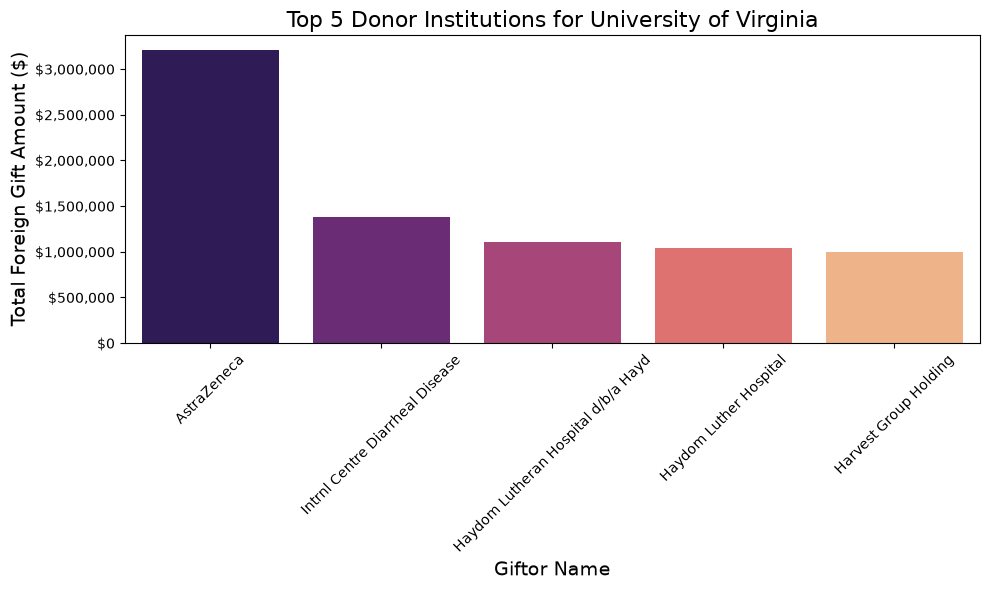

In [8]:

# Bar chart for top 5 institutions
plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_institutions, x='Giftor Name', y='Foreign Gift Amount', palette='magma')
plt.title('Top 5 Donor Institutions for University of Virginia', fontsize=16)
plt.xlabel('Giftor Name', fontsize=14)
plt.ylabel('Total Foreign Gift Amount ($)', fontsize=14)
# Format y-axis as currency
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.xticks(rotation=45)
plt.tight_layout()

In [9]:
# average gift amount by country
average_gift_by_country = uva_gifts.groupby('Country of Giftor')['Foreign Gift Amount'].agg(['mean', 'median']).sort_values(by=['mean', 'median'], ascending=False).reset_index().round(2)
average_gift_by_country.style.format({'mean': '${:,.2f}', 'median': '${:,.2f}'})

,Country of Giftor,mean,median
0,SWITZERLAND,"$1,000,000.00","$1,000,000.00"
1,TANZANIA,"$925,482.33","$1,035,339.00"
2,BERMUDA,"$900,000.00","$900,000.00"
3,GUERNSEY,"$500,000.00","$500,000.00"
4,BANGLADESH,"$422,858.90","$307,225.50"
5,SINGAPORE,"$402,500.00","$402,500.00"
6,SWEDEN,"$400,755.20","$133,055.00"
7,RWANDA,"$284,135.00","$284,135.00"
8,JAPAN,"$265,970.00","$265,970.00"
9,THE NETHERLANDS,"$181,417.50","$171,089.50"


In [10]:
uva_total_gift_amount = uva_gifts['Foreign Gift Amount'].sum().item()
uva_total_gift_amount


22189238

In [ ]:
# Average Gift Amount Analysis
uva_avg_gift_amount = uva_gifts['Foreign Gift Amount'].agg(['mean', 'median']).round(2)
uva_avg_gift_amount

mean      226420.8
median     80535.5
Name: Foreign Gift Amount, dtype: float64

In [48]:
# total amount of gift to all US universities
total_gift_amount_all_universities = df['Foreign Gift Amount'].sum()
total_gift_amount_all_universities_formatted = "${:,.2f}".format(total_gift_amount_all_universities)
total_gift_amount_all_universities_formatted

'$16,600,515,514.00'

In [27]:
university_percentage = df.groupby('Institution Name')['Foreign Gift Amount'].sum().reset_index().assign(Percentage=lambda x: (x['Foreign Gift Amount'] / df['Foreign Gift Amount'].sum() * 100).round(2))
university_percentage.style.format({'Foreign Gift Amount': '${:,.2f}', 'Percentage': '{:.2f}%'})

,Institution Name,Foreign Gift Amount,Percentage
0,Adelphi University,"$1,000,000.00",0.01%
1,Albert Einstein College of Medicine,"$4,252,385.00",0.03%
2,Alfred University,"$2,711,699.00",0.02%
3,American University (The),"$3,489,000.00",0.02%
4,Amherst College,"$778,723.00",0.00%
5,Arizona State University,"$112,606,405.00",0.68%
6,Auburn University Montgomery,"$1,419,838.00",0.01%
7,Babson College,"$43,776,133.00",0.26%
8,Ball State University,"$32,334,248.00",0.19%
9,Barnard College,"$2,700,000.00",0.02%


University of Virginia counted to 0.13% of total gifts received by all US universitites. 

In [50]:
#uva percentage
uva_percentage = uva_gifts['Foreign Gift Amount'].sum() / df['Foreign Gift Amount'].sum() * 100
uva_percentage_formatted = "{:.2f}%".format(uva_percentage)
uva_percentage_formatted

'0.13%'